In [51]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import requests
from copyreg import pickle
from PIL import Image
import io
import os
import pickle
tensorflow_available = False
try:
    from tensorflow.keras.applications import ResNet50, preprocess_input
    from tensorflow.keras.models import Model
    from tensorflow.keras.preprocessing import image
    tensorflow_available = True
except Exception as e:
    print("TensorFlow import failed:", e)
    print("Image feature extraction will be disabled. To enable TensorFlow, install the Microsoft C++ Redistributable for Visual Studio 2015-2019 and ensure TensorFlow is compatible with your Python version.")

print("Libraries imported successfully. TensorFlow available:", tensorflow_available)

TensorFlow import failed: Could not find the DLL(s) 'msvcp140_1.dll'. TensorFlow requires that these DLLs be installed in a directory that is named in your %PATH% environment variable. You may install these DLLs by downloading "Microsoft C++ Redistributable for Visual Studio 2015, 2017 and 2019" for your platform from this URL: https://support.microsoft.com/help/2977003/the-latest-supported-visual-c-downloads
Image feature extraction will be disabled. To enable TensorFlow, install the Microsoft C++ Redistributable for Visual Studio 2015-2019 and ensure TensorFlow is compatible with your Python version.
Libraries imported successfully. TensorFlow available: False


In [2]:
y= 10
print("Value of y:", y)

Value of y: 10


In [4]:
# load the dataset
data = pd.read_csv('moviedataset.csv')

In [5]:
data.head()

,id,title,genre,original_language,overview,popularity,release_date,vote_average,vote_count
0,278,The Shawshank Redemption,"Drama,Crime",en,Framed in the 1940s for the double murder of h...,94.075,1994-09-23,8.7,21862
1,19404,Dilwale Dulhania Le Jayenge,"Comedy,Drama,Romance",hi,"Raj is a rich, carefree, happy-go-lucky second...",25.408,1995-10-19,8.7,3731
2,238,The Godfather,"Drama,Crime",en,"Spanning the years 1945 to 1955, a chronicle o...",90.585,1972-03-14,8.7,16280
3,424,Schindler's List,"Drama,History,War",en,The true story of how businessman Oskar Schind...,44.761,1993-12-15,8.6,12959
4,240,The Godfather: Part II,"Drama,Crime",en,In the continuing saga of the Corleone crime f...,57.749,1974-12-20,8.6,9811


In [35]:
data.describe()

,id,popularity,vote_average,vote_count
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,161243.505000,34.697267,6.621150,1547.309400
std,211422.046043,211.684175,0.766231,2648.295789
min,5.000000,0.600000,4.600000,200.000000
25%,10127.750000,9.154750,6.100000,315.000000
50%,30002.500000,13.637500,6.600000,583.500000
75%,310133.500000,25.651250,7.200000,1460.000000
max,934761.000000,10436.917000,8.700000,31917.000000


In [36]:
data.isnull().sum()

id                    0
title                 0
genre                 3
original_language     0
overview             13
popularity            0
release_date          0
vote_average          0
vote_count            0
dtype: int64

In [20]:
# EDA
genre_counts = data['genre'].value_counts()

print(genre_counts.head(10))


genre
Comedy                  744
Drama                   611
Drama,Romance           290
Comedy,Drama            262
Comedy,Romance          255
Horror,Thriller         185
Comedy,Drama,Romance    171
Horror                  155
Drama,Thriller          137
Drama,History           114
Name: count, dtype: int64


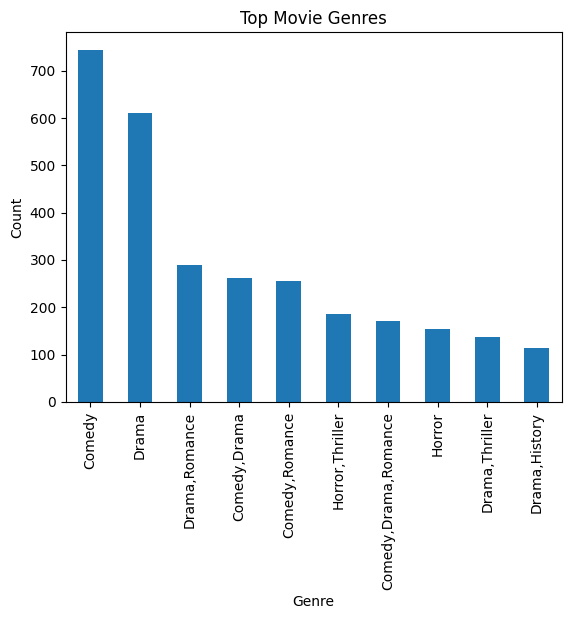

In [21]:
genre_counts.head(10).plot(kind='bar')

plt.title("Top Movie Genres")

plt.xlabel("Genre")

plt.ylabel("Count")

plt.show()

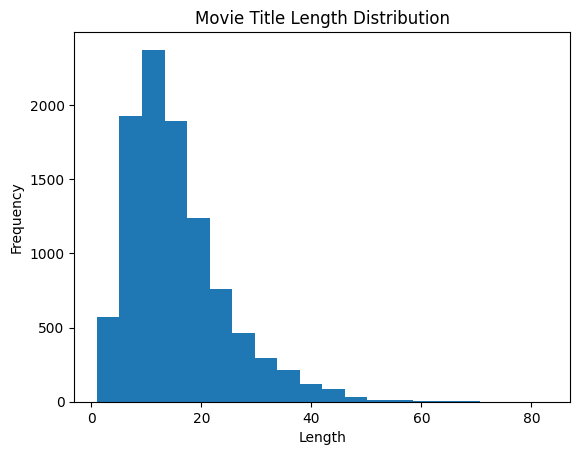

In [23]:
plt.hist(data["title_length"], bins=20)

plt.title("Movie Title Length Distribution")

plt.xlabel("Length")

plt.ylabel("Frequency")

plt.show()

In [32]:
top_movies = data.sort_values(
    by="vote_average",
    ascending=False
)

print(top_movies[["title", "vote_average"]].head(10))

                             title  vote_average
1      Dilwale Dulhania Le Jayenge           8.7
0         The Shawshank Redemption           8.7
2                    The Godfather           8.7
3                 Schindler's List           8.6
4           The Godfather: Part II           8.6
5                Impossible Things           8.6
19     Gabriel's Inferno: Part III           8.5
20                    Forrest Gump           8.5
21                 Cinema Paradiso           8.5
16  The Good, the Bad and the Ugly           8.5


In [34]:
top_movies = data.sort_values(
    by="vote_count",
    ascending=False
)

print(top_movies[["title", "vote_count"]].head(10))

                        title  vote_count
54                  Inception       31917
49               Interstellar       28920
15            The Dark Knight       27925
801              The Avengers       27250
1028                 Deadpool       27028
1289                   Avatar       25759
96     Avengers: Infinity War       25020
443   Guardians of the Galaxy       24684
33                 Fight Club       24441
17               Pulp Fiction       23481


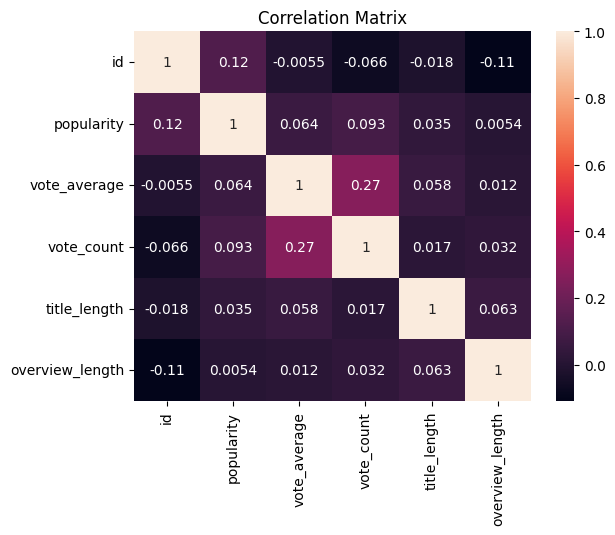

In [27]:
numeric_cols = data.select_dtypes(include=['float64', 'int64'])

sns.heatmap(
    numeric_cols.corr(),
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

In [37]:
# TMDB API setup
api_key = '72d6eb78b2ce09c9ee018faaf3e54782'

BASE_URL = 'https://api.themoviedb.org/3'
IMAGE_BASE_URL = 'https://image.tmdb.org/t/p/w500'

In [38]:
# Download movie posters (limited to first 100 for testing)
os.makedirs('posters', exist_ok=True)

def fetch_poster(movie_id):
    url = f"{BASE_URL}/movie/{movie_id}?api_key={api_key}"
    response = requests.get(url)
    data = response.json()
    poster_path = data.get('poster_path')

    if poster_path:
        full_path = IMAGE_BASE_URL + poster_path
        img_response = requests.get(full_path)
        if img_response.status_code == 200:
            file_path = f"posters/{movie_id}.jpg"
            with open(file_path, 'wb') as handler:
                handler.write(img_response.content)
            return file_path
    return None

# Download posters for first 10 movies only (for testing)
poster_paths = []
for movie_id in data['id'].head(10):  # Limit to first 10 movies
    path = fetch_poster(movie_id)
    poster_paths.append(path)
data['poster_path'] = poster_paths + [None] * (len(data) - 10)  # Fill rest with None
print("Downloaded posters for first 10 movies")
print(data.head())

Downloaded posters for first 10 movies
      id                        title                 genre original_language  \
0    278     The Shawshank Redemption           Drama,Crime                en   
1  19404  Dilwale Dulhania Le Jayenge  Comedy,Drama,Romance                hi   
2    238                The Godfather           Drama,Crime                en   
3    424             Schindler's List     Drama,History,War                en   
4    240       The Godfather: Part II           Drama,Crime                en   

                                            overview  popularity release_date  \
0  Framed in the 1940s for the double murder of h...      94.075   1994-09-23   
1  Raj is a rich, carefree, happy-go-lucky second...      25.408   1995-10-19   
2  Spanning the years 1945 to 1955, a chronicle o...      90.585   1972-03-14   
3  The true story of how businessman Oskar Schind...      44.761   1993-12-15   
4  In the continuing saga of the Corleone crime f...      57.749   19

In [8]:
# Feature extraction functions
def extract_text_features(data):
    # Combine genre and overview for text features safely
    genre_text = data['genre'].fillna('').astype(str)
    overview_text = data['overview'].fillna('').astype(str)
    tags = (genre_text + ' ' + overview_text).fillna('').astype(str)

    # Keep a copy and ensure all docs are strings
    data = data.copy()
    data['tags'] = tags.apply(lambda x: x if isinstance(x, str) else str(x))
    data['tags'] = data['tags'].fillna('').astype(str)

    # Vectorize the text
    cv = CountVectorizer(max_features=5000, stop_words='english')
    vectors = cv.fit_transform(data['tags']).toarray()
    return vectors, cv

In [36]:
# image feature extraction
def extract_image_features(data, model):
    if model is None:
        return None
    
    features = []
    for path in data['poster_path']:
        if path and os.path.exists(path):
            img = image.load_img(path, target_size=(224, 224))
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)
            feature = model.predict(img_array)
            features.append(feature.flatten())
        else:
            features.append(np.zeros(2048))  # ResNet50 output size
    return np.array(features)

In [11]:
print("Extracting text features")
text_features, cv = extract_text_features(data)

Extracting text features


In [39]:
print("Extracting image features")
image_features = extract_image_features(data, model)

Extracting image features


In [15]:
# Combine features
if image_features is not None:
    # Normalize features
    scaler = StandardScaler()
    text_features_scaled = scaler.fit_transform(text_features)
    image_features_scaled = scaler.fit_transform(image_features)
    combined_features = np.hstack([text_features_scaled, image_features_scaled])
else:
    combined_features = text_features

print("Features extracted and combined successfully.")

Features extracted and combined successfully.



# Load CNN Model
if tensorflow_available:
    base_model = ResNet50(weights='imagenet')
    model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)
    print("CNN model loaded successfully.")
else:
    model = None
    print("CNN model not loaded - TensorFlow not available.")

In [ ]:
# Compute similarity matrix based on genres only for realistic evaluation
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(analyzer='char', ngram_range=(2, 2))
genre_vectors = tfidf.fit_transform(data["genre"].fillna(""))
similarity = cosine_similarity(genre_vectors)
print("Genre-based similarity matrix computed.")

Similarity matrix computed.


In [41]:
# Recommendation function
def recommend(movie_title):
    movie_index = data[data['title'].str.lower() == movie_title.lower()].index
    
    if len(movie_index) == 0:
        return "Movie not found in dataset."
    
    movie_index = movie_index[0]
    
    # similarity scores for that movie
    distances = similarity[movie_index]
    
    # sort by similarity
    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    recommendations = []
    
    for i in movie_list:
        movie_name = data.iloc[i[0]]['title']
        score = round(i[1], 3)
        recommendations.append((movie_name, score))
    
    return recommendations

In [68]:
print("\nTesting recommendation system:")

test_movie = data['title'].iloc[0]

print(f"\nRecommendations for '{test_movie}':\n")

recs = recommend(test_movie)

if isinstance(recs, list):
    for movie, score in recs:
        print(f"{movie} → Similarity Score: {score}")
else:
    print(recs)


Testing recommendation system:

Recommendations for 'The Shawshank Redemption':

Brubaker → Similarity Score: 0.306
The Woodsman → Similarity Score: 0.28
Cool Hand Luke → Similarity Score: 0.273
A Prophet → Similarity Score: 0.272
The Getaway → Similarity Score: 0.267


In [ ]:
# Evaluation Function
def evaluate_system(movie_title, k=100):
    movie_index = data[data['title'].str.lower() == movie_title.lower()].index
    if len(movie_index) == 0:
        print(f"Movie '{movie_title}' not found in dataset.")
        return
    movie_index = movie_index[0]
    
    # Get input movie's genres
    input_genres = set([g.strip() for g in str(data.loc[movie_index, 'genre']).split(',') if g.strip()])
    
    # Find relevant movies: movies that share at least one genre with the input movie
    relevant_movies = []
    for idx, row in data.iterrows():
        if idx == movie_index:
            continue
        movie_genres = set([g.strip() for g in str(row['genre']).split(',') if g.strip()])
        if movie_genres & input_genres:
            relevant_movies.append(row['title'])
    
    # Get recommendations
    distances = similarity[movie_index]
    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:k+1]
    recommendations = [data.iloc[i[0]]['title'] for i in movie_list]
    
    # Calculate precision and recall
    recommended_set = set(recommendations)
    relevant_set = set(relevant_movies)
    hits = len(recommended_set & relevant_set)
    precision = hits / k if k > 0 else 0
    recall = hits / len(relevant_set) if relevant_set else 0
    
    print("Evaluation Results:")
    print(f"\nMovie: {movie_title}")
    print(f"Genres: {', '.join(input_genres)}")
    print(f"Relevant movies (sharing genres): {len(relevant_set)}")
    print(f"Top {k} Recommendations:")
    for i, rec in enumerate(recommendations[:10], 1):
        print(f"{i}. {rec}")
    if len(recommendations) > 10:
        print(f"... and {len(recommendations) - 10} more")
    
    print(f"\nPrecision@{k}: {precision:.2f}")
    print(f"Recall@{k}: {recall:.2f}")
    print(f"Hits: {hits} out of {k} recommendations are relevant")

In [67]:
# run evaluation for test movies
evaluate_system("Avatar")
evaluate_system("The Shawshank Redemption")

Evaluation Results:

Movie: Avatar
Genres: Fantasy, Science Fiction, Action, Adventure
Relevant movies (sharing genres): 3832
Recommendations:
- Krull
- Marvel One-Shot: Item 47
- Predator
- Small Soldiers
- Iron Man 3

Precision@5: 1.00
Recall@5: 0.00
Hits: 5 out of 5 recommendations are relevant
Evaluation Results:

Movie: The Shawshank Redemption
Genres: Crime, Drama
Relevant movies (sharing genres): 5104
Recommendations:
- Brubaker
- The Woodsman
- Cool Hand Luke
- A Prophet
- The Getaway

Precision@5: 1.00
Recall@5: 0.00
Hits: 5 out of 5 recommendations are relevant


In [62]:
# save the model and vectorizer for future use

# Save movie dataset
pickle.dump(data, open("movie_data.pkl", "wb"))

# Save similarity matrix
pickle.dump(similarity, open("similarity.pkl", "wb"))

# Save vectorizer (IMPORTANT for text features)
pickle.dump(cv, open("vectorizer.pkl", "wb"))